### **Name:** Atharva Tembhurnikar  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  **Branch:** CSE(AIML)
### **Roll No.:** 04 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; **Section:** C


### **Course:** Deep Learning Lab 25-26 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Batch:** C1


---


## **Aim:**
To design and develop an Artificial Neural Network (ANN) model for SONAR signal reflection prediction and evaluate the effect of different regularization techniques such as L1, L2, Dropout and Early Stopping.

####**Tasks:**

*   Perform EDA
*   Train and evaluate the
*   performance of model using appropriate metrics.
*   Display run time chart
*   Apply regularization technique like L1, L2, dropout and early stopping to
improve the performance of the model.
*   Experiment with individual or combination of regularization techniques.
* Provide comparative analysis
* Save the ANN model



## **Code**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

## **EDA on Sonar Dataset**

In [ ]:
df = pd.read_csv("Sonar_with_Column_Names.csv")

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V52,V53,V54,V55,V56,V57,V58,V59,V60,Class
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
...,...
V57,0
V58,0
V59,0
V60,0


In [ ]:
df["Class"].unique()

array(['R', 'M'], dtype=object)

In [ ]:
label = LabelEncoder()
df["Class"] = label.fit_transform(df["Class"])
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V52,V53,V54,V55,V56,V57,V58,V59,V60,Class
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,1


In [ ]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
model1 = Sequential()

## **Base Model  without Regularization**

In [ ]:
from tensorflow.keras.optimizers import Adam

model1.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))
model1.add(Dense(32, activation="relu"))
model1.add(Dense(1, activation="sigmoid"))

model1.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

history_base=model1.fit(
    x_train, y_train,
    epochs=20,
    verbose=0,
    validation_data=(x_test, y_test)
)

model1.evaluate(x_test, y_test)

print("Training Accuracy:", history_base.history['accuracy'][-1])
print("Validation Accuracy:", history_base.history['val_accuracy'][-1])

print("Training Loss:", history_base.history['loss'][-1])
print("Validation Loss:", history_base.history['val_loss'][-1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8889 - loss: 0.2518
Training Accuracy: 0.9931034445762634
Validation Accuracy: 0.8888888955116272
Training Loss: 0.11378171294927597
Validation Loss: 0.25177454948425293


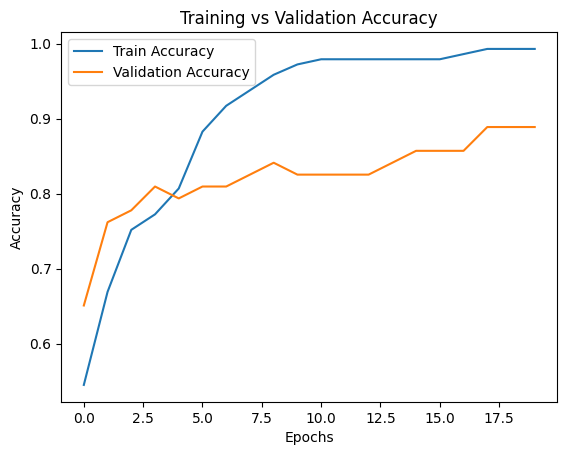

In [ ]:
plt.plot(history_base.history['accuracy'], label="Train Accuracy")
plt.plot(history_base.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### **L1 Regularization**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8413 - loss: 3.5961
Training Accuracy: 0.9241379499435425
Validation Accuracy: 0.841269850730896
Training Loss: 3.62786602973938
Validation Loss: 3.596137523651123


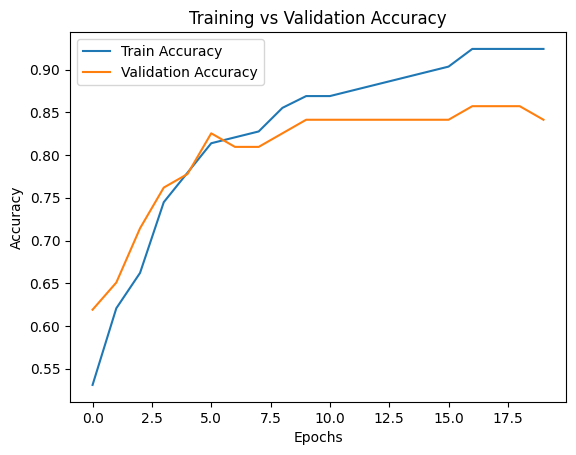

In [ ]:
model_l1 = Sequential()

model_l1.add(Dense(64, activation="relu",
                   kernel_regularizer=regularizers.l1(0.01),
                   input_shape=(x_train.shape[1],)))

model_l1.add(Dense(32, activation="relu",
                   kernel_regularizer=regularizers.l1(0.01)))

model_l1.add(Dense(1, activation="sigmoid"))

model_l1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_l1=model_l1.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=0
)

model_l1.evaluate(x_test, y_test)
print("Training Accuracy:", history_l1.history['accuracy'][-1])
print("Validation Accuracy:", history_l1.history['val_accuracy'][-1])

print("Training Loss:", history_l1.history['loss'][-1])
print("Validation Loss:", history_l1.history['val_loss'][-1])

plt.plot(history_l1.history['accuracy'], label="Train Accuracy")
plt.plot(history_l1.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### **L2 Regularization**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8730 - loss: 0.9524
Training Accuracy: 0.9724137783050537
Validation Accuracy: 0.8730158805847168
Training Loss: 0.8412029147148132
Validation Loss: 0.9524410367012024


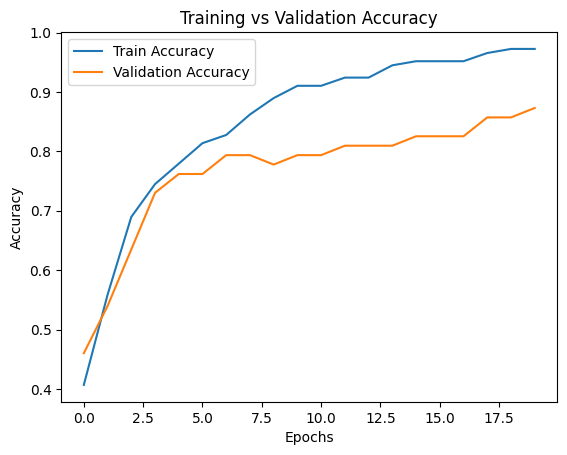

In [ ]:
model_l2 = Sequential()

model_l2.add(Dense(64, activation="relu",
                   kernel_regularizer=regularizers.l2(0.01),
                   input_shape=(x_train.shape[1],)))

model_l2.add(Dense(32, activation="relu",
                   kernel_regularizer=regularizers.l2(0.01)))

model_l2.add(Dense(1, activation="sigmoid"))

model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_l2=model_l2.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=0
)

model_l2.evaluate(x_test, y_test)
print("Training Accuracy:", history_l2.history['accuracy'][-1])
print("Validation Accuracy:", history_l2.history['val_accuracy'][-1])

print("Training Loss:", history_l2.history['loss'][-1])
print("Validation Loss:", history_l2.history['val_loss'][-1])

plt.plot(history_l2.history['accuracy'], label="Train Accuracy")
plt.plot(history_l2.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### **Dropout**

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5241 - loss: 0.9459 - val_accuracy: 0.7143 - val_loss: 0.5827
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5586 - loss: 0.8255 - val_accuracy: 0.7460 - val_loss: 0.5576
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6552 - loss: 0.7608 - val_accuracy: 0.7302 - val_loss: 0.5333
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5517 - loss: 0.7747 - val_accuracy: 0.7937 - val_loss: 0.5134
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6069 - loss: 0.7167 - val_accuracy: 0.8095 - val_loss: 0.4939
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6690 - loss: 0.6601 - val_accuracy: 0.8095 - val_loss: 0.4761
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6690 - loss: 0.6795 - val_accuracy: 0.8254 - val_loss: 0.4595
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6897 - loss: 0.6609 - val_accuracy: 0.8254 - val_loss: 0.4459
Epoch 9/20


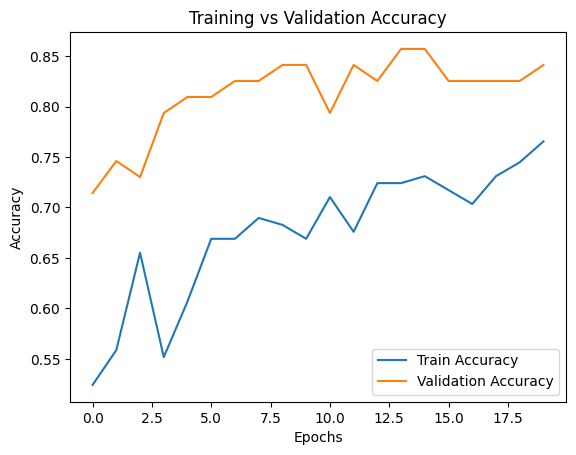

In [ ]:
from tensorflow.keras.layers import Dropout

model_dropout = Sequential()

model_dropout.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))
model_dropout.add(Dropout(0.5))

model_dropout.add(Dense(32, activation="relu"))
model_dropout.add(Dropout(0.5))

model_dropout.add(Dense(1, activation="sigmoid"))

model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_d=model_dropout.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

model_dropout.evaluate(x_test, y_test)

print("Training Accuracy:", history_d.history['accuracy'][-1])
print("Validation Accuracy:", history_d.history['val_accuracy'][-1])

print("Training Loss:", history_d.history['loss'][-1])
print("Validation Loss:", history_d.history['val_loss'][-1])

plt.plot(history_d.history['accuracy'], label="Train Accuracy")
plt.plot(history_d.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### **Early Stopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_es = Sequential()

model_es.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))
model_es.add(Dense(32, activation="relu"))
model_es.add(Dense(1, activation="sigmoid"))

model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_es=model_es.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

model_es.evaluate(x_test, y_test)

print("Training Accuracy:", history_es.history['accuracy'][-1])
print("Validation Accuracy:", history_es.history['val_accuracy'][-1])

print("Training Loss:", history_es.history['loss'][-1])
print("Validation Loss:", history_es.history['val_loss'][-1])

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.4759 - loss: 0.7783 - val_accuracy: 0.5079 - val_loss: 0.6889
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4897 - loss: 0.7286 - val_accuracy: 0.4921 - val_loss: 0.6544
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5034 - loss: 0.6890 - val_accuracy: 0.6349 - val_loss: 0.6242
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5586 - loss: 0.6548 - val_accuracy: 0.7143 - val_loss: 0.5978
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6690 - loss: 0.6231 - val_accuracy: 0.7619 - val_loss: 0.5758
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7103 - loss: 0.5963 - val_accuracy: 0.7937 - val_loss: 0.5569
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7379 - loss: 0.5714 - val_accuracy: 0.7937 - val_loss: 0.5389
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7862 - loss: 0.5500 - val_accuracy: 0.7778 - val_loss: 0.5228

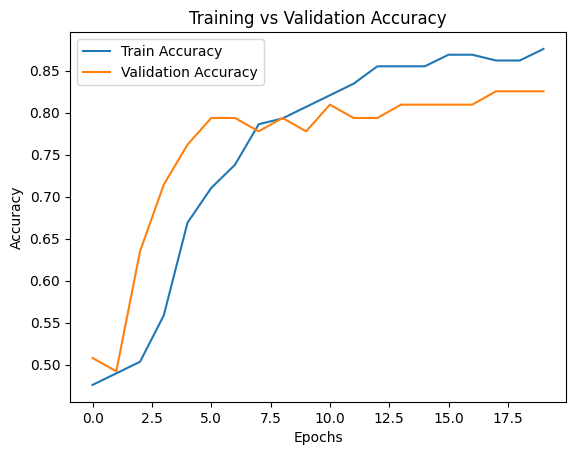

In [ ]:
plt.plot(history_es.history['accuracy'], label="Train Accuracy")
plt.plot(history_es.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## **L2 + Dropout Combination**

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5379 - loss: 1.7684 - val_accuracy: 0.6508 - val_loss: 1.6993
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5448 - loss: 1.7532 - val_accuracy: 0.7143 - val_loss: 1.6479
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6345 - loss: 1.6642 - val_accuracy: 0.7778 - val_loss: 1.5940
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6000 - loss: 1.6226 - val_accuracy: 0.7778 - val_loss: 1.5436
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7034 - loss: 1.5361 - val_accuracy: 0.8095 - val_loss: 1.4953
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7379 - loss: 1.5150 - val_accuracy: 0.8254 - val_loss: 1.4525
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7310 - loss: 1.4687 - val_accuracy: 0.8254 - val_loss: 1.4133
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7310 - loss: 1.4394 - val_accuracy: 0.8571 - val_loss: 1.3771


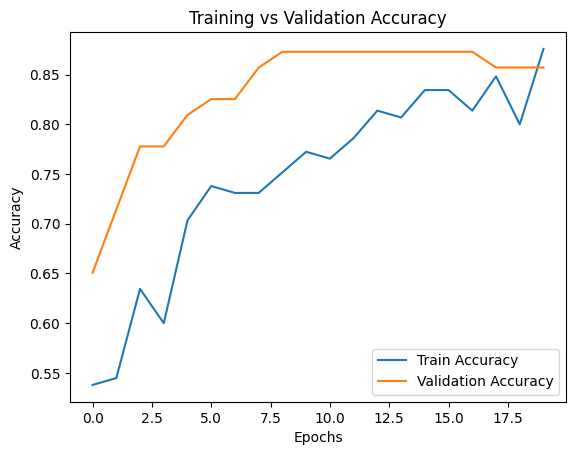

In [ ]:
model_combo1 = Sequential([
Dense(64, activation="relu",
      kernel_regularizer=regularizers.l2(0.01),
      input_shape=(x_train.shape[1],)),

Dropout(0.5),

Dense(32, activation="relu",
      kernel_regularizer=regularizers.l2(0.01)),



Dense(1, activation="sigmoid")
])

model_combo1.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

history_c1 = model_combo1.fit(
x_train, y_train,
epochs=20,
validation_data=(x_test, y_test),
verbose=1
)

model_combo1.evaluate(x_test, y_test)
print("Training Accuracy:", history_c1.history['accuracy'][-1])
print("Validation Accuracy:", history_c1.history['val_accuracy'][-1])

print("Training Loss:", history_c1.history['loss'][-1])
print("Validation Loss:", history_c1.history['val_loss'][-1])

plt.plot(history_c1.history['accuracy'], label="Train Accuracy")
plt.plot(history_c1.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## **L2 + Early Stopping Combination**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9206 - loss: 0.4989
Training Accuracy: 1.0
Validation Accuracy: 0.920634925365448
Training Loss: 0.36184200644493103
Validation Loss: 0.49885305762290955


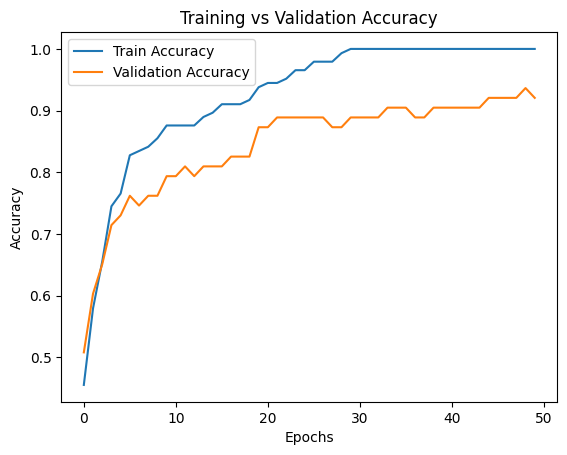

In [ ]:
early_stop = EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True
)

model_combo2 = Sequential([
Dense(64, activation="relu",
      kernel_regularizer=regularizers.l2(0.01),
      input_shape=(x_train.shape[1],)),

Dense(32, activation="relu",
      kernel_regularizer=regularizers.l2(0.01)),

Dense(1, activation="sigmoid")
])

model_combo2.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

history_c2= model_combo2.fit(
x_train, y_train,
epochs=50,
validation_data=(x_test, y_test),
callbacks=[early_stop],
verbose=0
)

model_combo2.evaluate(x_test, y_test)
print("Training Accuracy:", history_c2.history['accuracy'][-1])
print("Validation Accuracy:", history_c2.history['val_accuracy'][-1])

print("Training Loss:", history_c2.history['loss'][-1])
print("Validation Loss:", history_c2.history['val_loss'][-1])

plt.plot(history_c2.history['accuracy'], label="Train Accuracy")
plt.plot(history_c2.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
model1.save("sonar_ann_model.h5")